# Pre-stimulus decodability with a drift-preserving null (per Cosmos region)
Decode a trial variable (`TARGET`) from **pre-stimulus** window-averaged activity, leak-free PCA+LDA CV,
balanced-accuracy. `REGION_MODE='per_region'` decodes within each Cosmos region; `'pooled'` uses all neurons.
Two nulls per unit:
- **shuffle**: permute labels (destroys temporal structure) -> pure chance
- **circular shift**: roll the chronological label sequence (keeps slow run structure, misaligns with drift)
  -> **drift-preserving null**. real >> circular = genuine trial-by-trial signal; real ~ circular = drift.

`TARGET`: `'feedback'` (correct/error), `'stim'` (pre-stim **negative control** -> chance), `'choice'`, `'block'` (**positive control**).

In [1]:
import numpy as np, pandas as pd, pickle, os, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white'

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
DROP = ['root', 'void']
out_path = prefix + 'neural/decoding/decode_prestim_perregion.parquet'

TARGET = 'feedback'        # 'feedback' | 'stim' | 'choice' | 'block'
WINDOWS = {'-0.2..0': (-0.2, 0.0), '-0.5..-0.1': (-0.5, -0.1)}
REGION_MODE = 'per_region' # 'per_region' (per Cosmos) | 'pooled' (all neurons)
N_SESSIONS = 12            # sessions to run (more -> better per-region sampling)
MIN_REGION_NEURONS = 20    # per_region: skip regions with fewer neurons
MAX_NEURONS = None         # optional cap per unit (random subsample); None = all
K = 20                     # PCA components
CV_FOLDS = 5
N_NULL = 100               # draws per null (shuffle & circular)
MIN_CLASS = 30             # session must have >= this many trials in the minority target class
MIN_SHIFT_FRAC = 0.1
MIN_REGION_SESSIONS = 3    # only plot regions seen in >= this many sessions
SEED = 0
rng = np.random.default_rng(SEED)

trials_df = pd.read_parquet(prefix + '4_mice/all_trials_04-05-2026')
idx = pd.read_parquet(prefix + 'neural/decoding/firing_session_pid_index.parquet')
neurons_per_session = idx.groupby('session')['n_neurons'].sum()
br = BrainRegions()
print(f"TARGET={TARGET} | mode={REGION_MODE} | windows={list(WINDOWS)}")

TARGET=feedback | mode=per_region | windows=['-0.2..0', '-0.5..-0.1']


## Helpers

In [3]:
def make_folds(X, y):
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); folds = []
    for tr, te in skf.split(X, y):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(K, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=SEED).fit(Xtr)
        folds.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return folds

def acc_labels(folds, y):
    a = []
    for tr, te, Ztr, Zte in folds:
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr, y[tr]).predict(Zte)))
    return np.nanmean(a)

def circular_nulls(folds, y_chrono, n_null, rng):
    n = len(y_chrono); lo = max(1, int(MIN_SHIFT_FRAC * n)); accs = []
    for _ in range(n_null):
        s = int(rng.integers(lo, n - lo)); accs.append(acc_labels(folds, np.roll(y_chrono, s)))
    return np.array(accs)

def target_labels(lab):
    choice_code = (lab['choice'].values == 'right').astype(float)
    correct = lab['correct'].values; contrast = lab['contrast'].values; block = lab['block'].values
    if TARGET == 'feedback': return ~np.isnan(correct), correct
    if TARGET == 'stim':     return contrast > 0, np.where(correct == 1, choice_code, 1 - choice_code)
    if TARGET == 'choice':   return ~np.isnan(choice_code), choice_code
    if TARGET == 'block':    return np.isin(block, [0.2, 0.8]), (block == 0.8).astype(float)
    raise ValueError(TARGET)

def load_windows(eid):
    pivs = {w: [] for w in WINDOWS}; area_map = {}
    for fn in idx.loc[idx.session == eid, 'filename']:
        d = pickle.load(open(firing_rates_dir + fn, 'rb'))
        d = d[~d['area'].isin(DROP)].copy()
        if len(d) == 0: continue
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        area_map.update(dict(zip(d['nuid'], d['area'])))
        tcols = sorted([c for c in d.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
        tsec = np.array([float(c.split('_')[1]) for c in tcols])
        for w, (a, b) in WINDOWS.items():
            cols = [c for c, mm in zip(tcols, (tsec >= a) & (tsec <= b)) if mm]
            d[w] = d[cols].mean(axis=1)
            pivs[w].append(d.pivot_table(index='trial_id', columns='nuid', values=w))
    Xw = {w: pd.concat(v, axis=1) for w, v in pivs.items()}
    nuids = list(Xw[list(WINDOWS)[0]].columns)
    ac = pd.Series({n: area_map[n] for n in nuids}); uac = ac.dropna().unique()
    cmap = dict(zip(uac, br.acronym2acronym(uac, mapping='Cosmos')))
    return Xw, ac.map(cmap)      # region Series indexed by nuid (aligned to columns)

def region_units(reg):
    if REGION_MODE == 'per_region':
        u = []
        for r in pd.unique(reg.values):
            if not isinstance(r, str): continue
            cols = list(reg.index[reg.values == r])
            if len(cols) >= MIN_REGION_NEURONS: u.append((r, cols))
        return u
    return [('all-pooled', list(reg.index))]

## Pick sessions + decode per region (real, shuffle, circular-shift)

In [4]:
picked = []
for eid in neurons_per_session.sort_values(ascending=False).index:
    if eid not in set(idx.session): continue
    mask, y = target_labels(trials_df[trials_df.session == eid].set_index('trial_id'))
    yv = y[mask]; yv = yv[~np.isnan(yv)]
    if len(np.unique(yv)) == 2 and np.bincount(yv.astype(int)).min() >= MIN_CLASS: picked.append(eid)
    if len(picked) >= N_SESSIONS: break

records = []
for si, eid in enumerate(picked):
    Xw, reg = load_windows(eid); lab = trials_df[trials_df.session == eid].set_index('trial_id')
    for label, cols in region_units(reg):
        cc = cols if (not MAX_NEURONS or len(cols) <= MAX_NEURONS) else list(rng.choice(cols, MAX_NEURONS, replace=False))
        for w in WINDOWS:
            X = Xw[w][cc]; lab_w = lab.reindex(X.index); mask, y = target_labels(lab_w)
            good = mask & ~np.isnan(y) & ~np.isnan(X.values).any(axis=1)
            Xg, yg = X.values[good], y[good].astype(int)
            if len(np.unique(yg)) < 2 or np.bincount(yg).min() < CV_FOLDS: continue
            folds = make_folds(Xg, yg)
            real = acc_labels(folds, yg)
            shuf = np.array([acc_labels(folds, rng.permutation(yg)) for _ in range(N_NULL)])
            circ = circular_nulls(folds, yg, N_NULL, rng)
            records.append(dict(session=eid, region=label, window=w, n_neurons=len(cc), n_trials=len(yg),
                                real=real, circ_mean=circ.mean(), circ_std=circ.std(), shuf_mean=shuf.mean(),
                                z_circ=(real - circ.mean()) / (circ.std() + 1e-9)))
    print(f"  {si+1}/{len(picked)} {eid[:8]} done")
res = pd.DataFrame(records)
res.to_parquet(out_path)
print(f"\nsaved {len(res)} (session x region x window) rows -> {out_path}")
print(res.groupby(['window'])['real'].agg(['mean', 'std', 'count']))

  1/12 d33baf74 done


  2/12 746d1902 done


  3/12 4ecb5d24 done


  4/12 ee40aece done


  5/12 4a45c8ba done


...

  8/12 1a507308 done


  9/12 2bdf206a done


  10/12 8a3a0197 done


  11/12 111c1762 done


  12/12 09394481 done

saved 82 (session x region x window) rows -> /home/ines/repositories/representation_learning_variability/paper-individuality/neural/decoding/decode_prestim_perregion.parquet
                mean       std  count
window                               
-0.2..0     0.521522  0.060600     41
-0.5..-0.1  0.519367  0.065201     41


## Visualization (per region, loads from parquet)

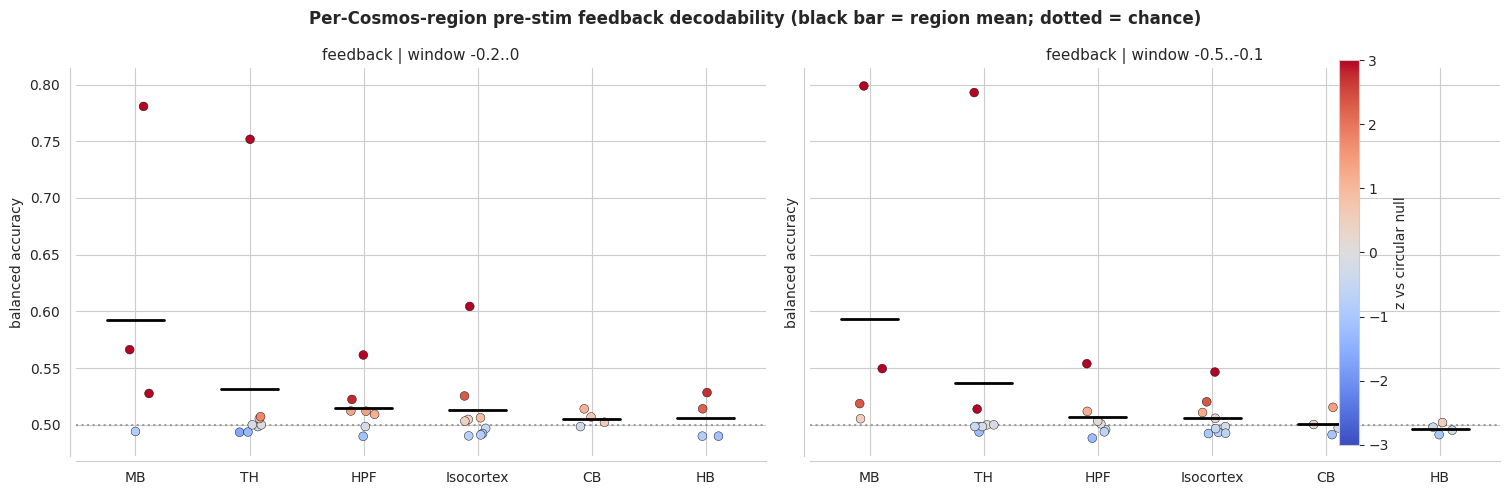

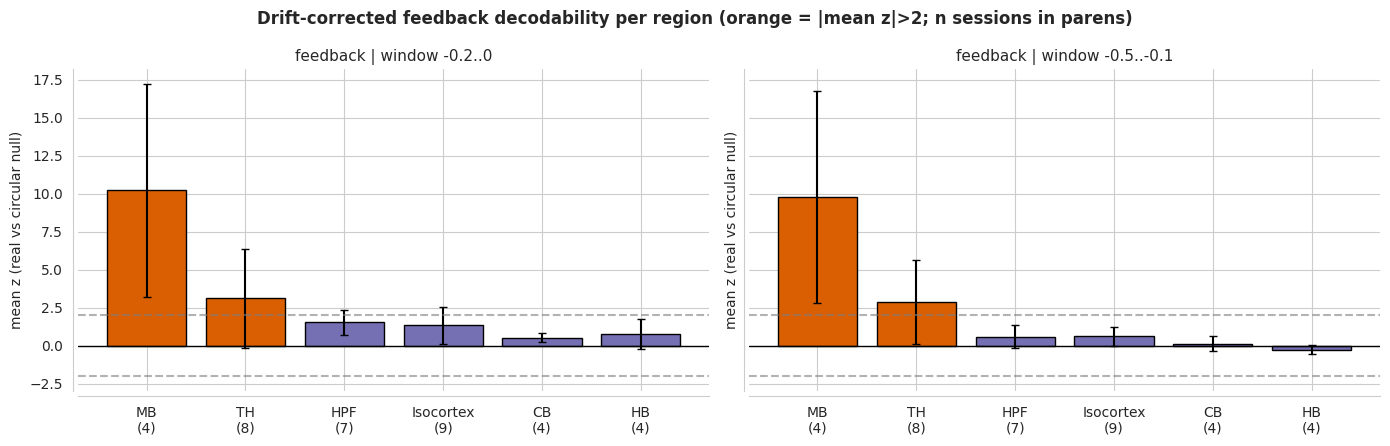

per region x window: mean real / mean circular-null / mean z / n sessions
                       real   circ       z  n
region    window                             
CB        -0.2..0     0.505  0.500   0.502  4
          -0.5..-0.1  0.501  0.500   0.132  4
HB        -0.2..0     0.506  0.500   0.754  4
          -0.5..-0.1  0.497  0.500  -0.286  4
HPF       -0.2..0     0.515  0.500   1.541  7
          -0.5..-0.1  0.507  0.500   0.573  7
Isocortex -0.2..0     0.513  0.500   1.332  9
          -0.5..-0.1  0.506  0.501   0.615  9
MB        -0.2..0     0.592  0.501  10.216  4
          -0.5..-0.1  0.593  0.500   9.775  4
TH        -0.2..0     0.531  0.500   3.109  8
          -0.5..-0.1  0.537  0.500   2.846  8


In [5]:
res = pd.read_parquet(out_path)
regs_ok = res.groupby('region')['session'].nunique(); regs_ok = regs_ok[regs_ok >= MIN_REGION_SESSIONS].index.tolist()
rp = res[res.region.isin(regs_ok)]
order = rp.groupby('region')['z_circ'].mean().sort_values(ascending=False).index.tolist()

# (1) per-session real accuracy per region, colored by z vs circular null
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(1.1 * len(order) * len(WINDOWS) + 2, 5), squeeze=False, sharey=True)
for ax, w in zip(axes[0], WINDOWS):
    g = rp[rp.window == w]
    for i, r in enumerate(order):
        gr = g[g.region == r]; xj = i + rng.uniform(-0.12, 0.12, len(gr))
        sc = ax.scatter(xj, gr['real'], c=gr['z_circ'], cmap='coolwarm', vmin=-3, vmax=3, s=40, edgecolor='k', linewidth=0.3, zorder=3)
        ax.plot([i - 0.25, i + 0.25], [gr['real'].mean()] * 2, color='k', lw=2, zorder=4)
    ax.axhline(0.5, color='gray', ls=':', alpha=0.7)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_title(f"{TARGET} | window {w}", fontsize=11); ax.set_ylabel('balanced accuracy'); sns.despine(ax=ax, offset=4)
cbar = fig.colorbar(sc, ax=axes[0], fraction=0.02, pad=0.02); cbar.set_label('z vs circular null')
fig.suptitle(f"Per-Cosmos-region pre-stim {TARGET} decodability (black bar = region mean; dotted = chance)", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# (2) mean z vs circular null per region (bars, +/- SEM across sessions)
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(1.0 * len(order) * len(WINDOWS) + 2, 4.5), squeeze=False, sharey=True)
for ax, w in zip(axes[0], WINDOWS):
    g = rp[rp.window == w].groupby('region')['z_circ'].agg(['mean', 'sem', 'count']).reindex(order)
    colors = ['#d95f02' if abs(m) > 2 else '#7570b3' for m in g['mean']]
    ax.bar(range(len(order)), g['mean'], yerr=g['sem'], color=colors, edgecolor='k', capsize=3)
    ax.axhline(0, color='k', lw=1); ax.axhline(2, color='gray', ls='--', alpha=0.6); ax.axhline(-2, color='gray', ls='--', alpha=0.6)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([f"{r}\n({int(g.loc[r,'count'])})" for r in order], rotation=45, ha='right', fontsize=8)
    ax.set_title(f"{TARGET} | window {w}", fontsize=11); ax.set_ylabel('mean z (real vs circular null)'); sns.despine(ax=ax, offset=4)
fig.suptitle(f"Drift-corrected {TARGET} decodability per region (orange = |mean z|>2; n sessions in parens)", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("per region x window: mean real / mean circular-null / mean z / n sessions")
print(rp.groupby(['region', 'window']).agg(real=('real','mean'), circ=('circ_mean','mean'),
      z=('z_circ','mean'), n=('session','nunique')).round(3).to_string())